# The factory, from the ground up

**What this notebook is.** The companion to `CBP-Vet_Input-Anatomy.ipynb`. That one dissects the finished product, one event as a 37-number vector. This one opens the factory that *made* the event: the machinery that runs before any row exists. Same rules: real sources, live demonstrations, every code line commented.

**The assembly line, in order:** draw a shape (the Sobol bank) → choose where to plant it (the histogram epoch sampler) → flip the coin and mask (the dual-inversion harness) → maybe add a partner (the pair model) → search and harvest (label stamping) → assemble records (the exporter) → cut the split, flag the balance, and gate with probes. Each station below is one section.

In [1]:
import os, json, inspect                  # paths, artifacts, and reading real source code
import numpy as np                         # numeric work
import matplotlib.pyplot as plt            # plots
import sys; sys.path.insert(0, os.path.expanduser('~/cbp-vet'))   # our package importable
os.chdir(os.path.expanduser('~/cbp-vet'))                          # run from the repo root
rng = np.random.default_rng(7)             # one seeded generator: every demo reproduces exactly

## 1. Station one: the shape bank, and why Sobol

A training set of shapes must *cover* shape space, not clump in it. The demo below is the whole argument in one figure: 256 random points clump and leave holes; 256 Sobol points spread evenly by construction. Our bank drew 16,384 profiles this way over depth, duration, impact parameter, and asymmetry, so no region of shape space is accidentally unrepresented for the model to fail in later.

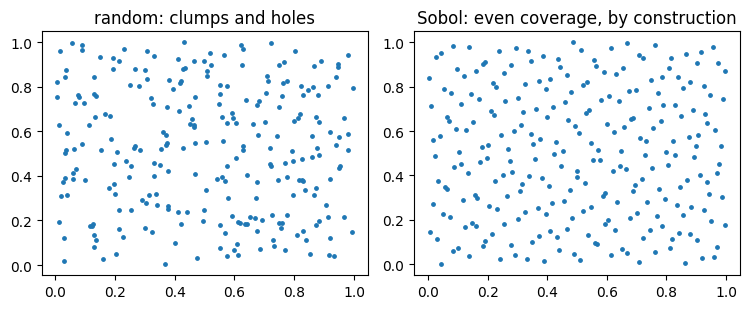

real bank: 16384 profiles;  axes: see manifest


In [2]:
from scipy.stats import qmc                                # quasi-Monte-Carlo tools; qmc.Sobol is the engine
sob = qmc.Sobol(d=2, seed=7).random(256)                   # 256 Sobol points in the unit square
ran = rng.random((256, 2))                                 # 256 plain random points, same square
fig, ax = plt.subplots(1, 2, figsize=(7.6, 3.2))           # side-by-side comparison
ax[0].scatter(*ran.T, s=6); ax[0].set(title='random: clumps and holes')
ax[1].scatter(*sob.T, s=6); ax[1].set(title='Sobol: even coverage, by construction')
plt.tight_layout(); plt.show()                             # render

bank = json.load(open('data/profile_bank_v2/bank_v2_config.json'))   # the real bank's recorded recipe
print('real bank:', bank['n_profiles'], 'profiles;  axes:', ', '.join(list(bank['axes'])[:6]) if 'axes' in bank else 'see manifest')

## 2. Station two: choosing where to plant

Uniform placement would be a fingerprint (real junk clusters near gaps and eclipses; injections on clean stretches would be separable by address alone). So the sampler holds the real negatives' joint histogram over two coordinates, phase distance to eclipse and time to nearest gap, picks a *bin* with probability proportional to real-junk density, then picks a cadence inside that bin. Bin-first is the subtle part: it makes the drawn epochs follow the 2-D *joint*, not each margin separately. Below, its real core.

In [3]:
from cbpvet.injection import epoch_sampler as es           # the placement machinery
src = inspect.getsource(es.HistogramEpochSampler.__call__)  # the draw itself
wx = src.find('probabilities')                              # jump toward the bin-weighted choice
seg = src[wx-300:wx+220] if wx > 300 else src[:520]        # a window around the weighted draw
print(seg)                                                 # bin chosen by density, cadence inside bin

/Users/wilsonwu/miniforge3/envs/mono-cbp/lib/python3.9/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


    def __call__(self, time, mask_indices, phase, meta):
        key = (meta["tic"], meta["sector"])
        flat_idx = self._bins_for_file(key, time, phase, meta["tic"])
        eligible_bins = flat_idx[mask_indices]

        for attempt in range(MAX_BIN_REDRAWS):
            target = self.rng.choice(len(self.bin_p), p=self.bin_p)
            hits = mask_indices[eligible_bins == target]
            if len(hits):
                self.counters["bin_hit" if attempt == 0 else "redraw"] += 1
                return floa


## 3. Station three: the coin flip and the mask

The injector decides per test whether this curve runs inverted (the completeness trick) or native. On the native half the trick no longer protects the label, so every event the real search already found is masked out before an epoch is drawn: the injection cannot land on top of real junk and steal its identity. Both mechanisms below are the real lines.

In [4]:
lines = open('cbpvet/injection/dual_injector.py').readlines()   # the engine's file
print(''.join(lines[277:286]))                             # the coin flip: rng < p_invert, flux *= -1 branch
print('...')
msrc = inspect.getsource(__import__('cbpvet.injection.dual_injector', fromlist=['DualInjector']).DualInjector._mask_real_events)
print(msrc[:msrc.find('\n\n')])                            # the native-arm mask: its contract, in its own words

        inverted = bool(self.rng.random() < self.p_invert)
        if inverted:
            flux = ((flux - 1) * -1) + 1

        # ---- DELTA 2: native path masks the real search's own events -----
        epoch_mask = mask
        n_blocked = 0
        if not inverted:
            epoch_mask, n_blocked = self._mask_real_events(time, mask, tic, sector, duration_model)

...
    def _mask_real_events(self, time, mask, tic, sector, duration_model):
        """Native path only: forbid epochs near events the real search already found.


## 4. Station four: the pair machinery

When a test injects a pair, three numbers must be physical: the spacing (resampled from the twelve *observed* spacings in the mentor's paper, conditioned on the period ratio), the depth ratio (drawn from quantiles fitted to 1,399 ELC dynamical pairs), and the duration ratio (ELC-measured, provisional). The demo draws 2,000 spacings from the real model and lays the twelve observed values on top: the factory's spacings live exactly where nature's do.

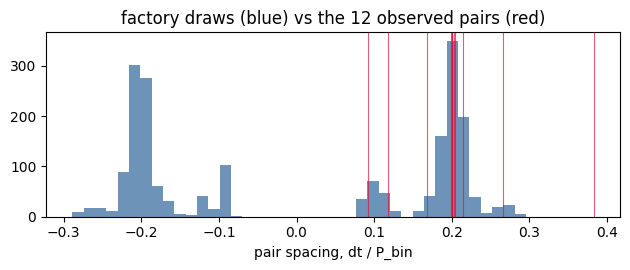

depth-ratio model: ELC-fitted quantile table, first/median/last: [4.0000e-03 6.5000e-01 1.1235e+01]


In [5]:
from cbpvet.injection import pair_model as pm              # the calibrated pair models
dts = pm.pair_spacing(rng, p_bin=10.0, p_planet=40.0,       # 2,000 spacings for a 10-day binary
                      duration_days=0.3, size=2000) / 10.0  # ...normalized to dt / P_bin
plt.figure(figsize=(6.4, 2.8))
plt.hist(dts, bins=40, color='#4878a8', alpha=0.8)          # what the factory draws
for v in pm.DT_OVER_PBIN:                                   # the twelve OBSERVED spacings (Kostov Table 1)
    plt.axvline(v, color='crimson', lw=0.8, alpha=0.7)
plt.xlabel('pair spacing, dt / P_bin'); plt.title('factory draws (blue) vs the 12 observed pairs (red)')
plt.tight_layout(); plt.show()
print('depth-ratio model: ELC-fitted quantile table, first/median/last:',
      np.round(pm.ELC_GEOMETRIC_FACTOR[[0, len(pm.ELC_GEOMETRIC_FACTOR)//2, -1]], 3))

## 5. Station five: harvest and the split, verified from the product

After the search runs on an injected curve, every flagged event within half a duration of the planted epoch is labeled 1; everything else flagged is labeled 0 (the anatomy notebook shows that stamp's source). Then the dataset is cut **by star, never by event**: all events of one binary land in exactly one of train, val, test, because two events of the same star share systematics a model could memorize. That claim is checkable in ten lines against the frozen file, so we check it rather than assert it.

In [6]:
import h5py                                                # the frozen benchmark's format
f = h5py.File('data/bench/full/bench_full.h5', 'r')        # open read-only
tic = f['scalars']['tic'][:]                               # each event's star id
sp = f['scalars']['split'][:].astype(str)                  # each event's split tag
sets = {s: set(tic[sp == s]) for s in ('train', 'val', 'test')}   # the stars in each split
print({k: len(v) for k, v in sets.items()}, 'distinct stars per split')
print('train & val overlap :', len(sets['train'] & sets['val']))    # must be 0
print('train & test overlap:', len(sets['train'] & sets['test']))   # must be 0
print('val & test overlap  :', len(sets['val'] & sets['test']))     # must be 0

{'train': 393, 'val': 92, 'test': 99} distinct stars per split
train & val overlap : 0
train & test overlap: 0
val & test overlap  : 0


## 6. Station six: the balance flag, verified the same way

The native arm harvests more negatives than the inverted arm (real dips survive there and get flagged), so the raw negative class leans native, a learnable fingerprint. The fix marks a subset with the mix equalized; nothing is deleted. Verify: compute the inverted fraction of each class, raw and flagged, straight from the file.

In [7]:
lab = f['scalars']['label'][:]                             # the answer key
inv = f['scalars']['inverted_lc'][:]                       # audit column: was this curve inverted
keep = f['scalars']['rebalance_keep'][:] == 1              # the balance flag
for name, m in (('raw', np.ones_like(lab, bool)), ('flagged subset', keep)):   # before vs after
    gp = inv[(lab == 1) & m].mean()                        # positives' inverted rate
    gn = inv[(lab == 0) & m].mean()                        # negatives' inverted rate
    print(f"{name:15s}: positives {gp:.4f} vs negatives {gn:.4f}  gap {abs(gp-gn):.2e}")

raw            : positives 0.5089 vs negatives 0.3958  gap 1.13e-01
flagged subset : positives 0.5089 vs negatives 0.5089  gap 4.65e-06


## 7. The gate at the factory door

Nothing above earns trust by intent; it earns it by surviving the probes (anatomy notebook section 9 territory, results in `probe_results.json`). The factory's whole honesty argument in one sentence: every station either copies reality (negatives, placement, spacing), is calibrated against physics (pair depths, durations), or is symmetrized away (inversion, balance), and whatever fingerprint survives anyway must show up when a strong model is paid to find it. The stations you just watched are why three probes pass; the disclosed failures and their dispositions are in the anatomy notebook and the frozen datasheet.

**The relay handoff:** an event leaving this factory is exactly what `CBP-Vet_Input-Anatomy.ipynb` picks up at its section 1, one row in the frozen file, 37 questions answered, ready to be scored.